In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df=pd.read_csv(r"C:\Users\Sanja\Downloads\Netflix TV Shows and Movies.csv")

In [3]:
df.head()

,index,id,title,type,description,release_year,age_certification,runtime,imdb_id,imdb_score,imdb_votes
0,0,tm84618,Taxi Driver,MOVIE,A mentally unstable Vietnam War veteran works ...,1976,R,113,tt0075314,8.3,795222.0
1,1,tm127384,Monty Python and the Holy Grail,MOVIE,"King Arthur, accompanied by his squire, recrui...",1975,PG,91,tt0071853,8.2,530877.0
2,2,tm70993,Life of Brian,MOVIE,"Brian Cohen is an average young Jewish man, bu...",1979,R,94,tt0079470,8.0,392419.0
3,3,tm190788,The Exorcist,MOVIE,12-year-old Regan MacNeil begins to adapt an e...,1973,R,133,tt0070047,8.1,391942.0
4,4,ts22164,Monty Python's Flying Circus,SHOW,A British sketch comedy series with the shows ...,1969,TV-14,30,tt0063929,8.8,72895.0


# Data Cleaning

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.shape

(5283, 11)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5283 entries, 0 to 5282
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   index              5283 non-null   int64  
 1   id                 5283 non-null   str    
 2   title              5283 non-null   str    
 3   type               5283 non-null   str    
 4   description        5278 non-null   str    
 5   release_year       5283 non-null   int64  
 6   age_certification  2998 non-null   str    
 7   runtime            5283 non-null   int64  
 8   imdb_id            5283 non-null   str    
 9   imdb_score         5283 non-null   float64
 10  imdb_votes         5267 non-null   float64
dtypes: float64(2), int64(3), str(6)
memory usage: 454.1 KB


In [7]:
df.isna().sum()

index                   0
id                      0
title                   0
type                    0
description             5
release_year            0
age_certification    2285
runtime                 0
imdb_id                 0
imdb_score              0
imdb_votes             16
dtype: int64

In [8]:
df['age_certification']=df['age_certification'].fillna("Unknown")

In [9]:
df.isna().sum()

index                 0
id                    0
title                 0
type                  0
description           5
release_year          0
age_certification     0
runtime               0
imdb_id               0
imdb_score            0
imdb_votes           16
dtype: int64

In [10]:
df['imdb_votes']=df.groupby('type')['imdb_votes'].transform(lambda x:x.fillna(x.median()))

In [11]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
index,5283.0,2641.000000,1525.215067,0.0,1320.5,2641.0,3961.5,5282.0
release_year,5283.0,2015.879992,7.346098,1953.0,2015.0,2018.0,2020.0,2022.0
runtime,5283.0,79.199886,38.915974,0.0,45.0,87.0,106.0,235.0
imdb_score,5283.0,6.533447,1.160932,1.5,5.8,6.6,7.4,9.6
imdb_votes,5283.0,23344.275601,87009.734634,5.0,522.0,2285.0,10097.0,2268288.0


In [12]:
df.drop(columns='description',inplace=True)


In [13]:
df.drop(columns=['id','imdb_id'],inplace=True)

In [14]:
df.head()

,index,title,type,release_year,age_certification,runtime,imdb_score,imdb_votes
0,0,Taxi Driver,MOVIE,1976,R,113,8.3,795222.0
1,1,Monty Python and the Holy Grail,MOVIE,1975,PG,91,8.2,530877.0
2,2,Life of Brian,MOVIE,1979,R,94,8.0,392419.0
3,3,The Exorcist,MOVIE,1973,R,133,8.1,391942.0
4,4,Monty Python's Flying Circus,SHOW,1969,TV-14,30,8.8,72895.0


## Exploratory Data Analysis

In [15]:
df['type'].value_counts()

type
MOVIE    3407
SHOW     1876
Name: count, dtype: int64

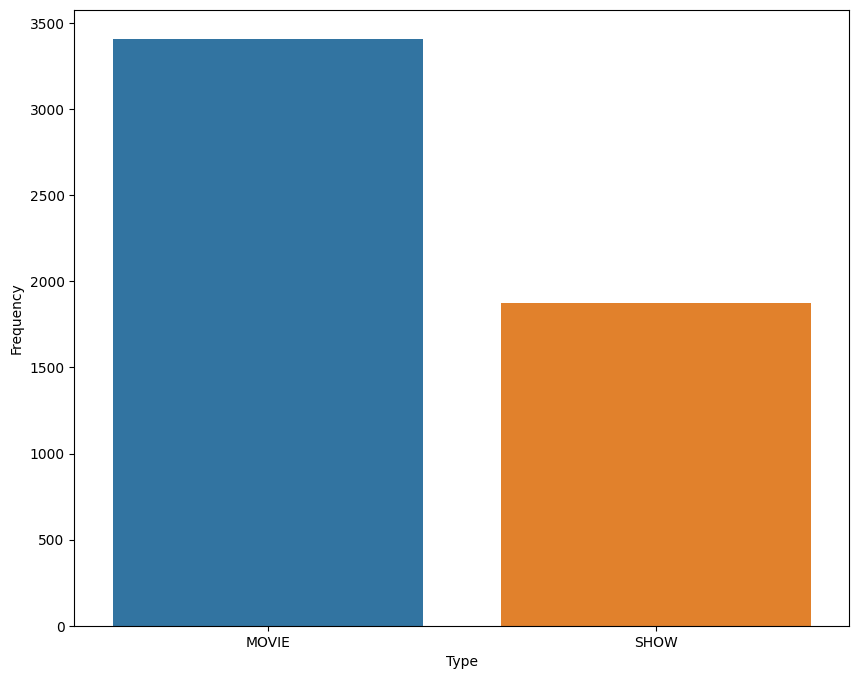

In [16]:
plt.figure(figsize=(10,8))
sns.countplot(data=df,x='type',hue='type')
plt.xlabel("Type")
plt.ylabel("Frequency")
plt.show()

                     Number of Movies in Netflix is Almost double of TV Shows

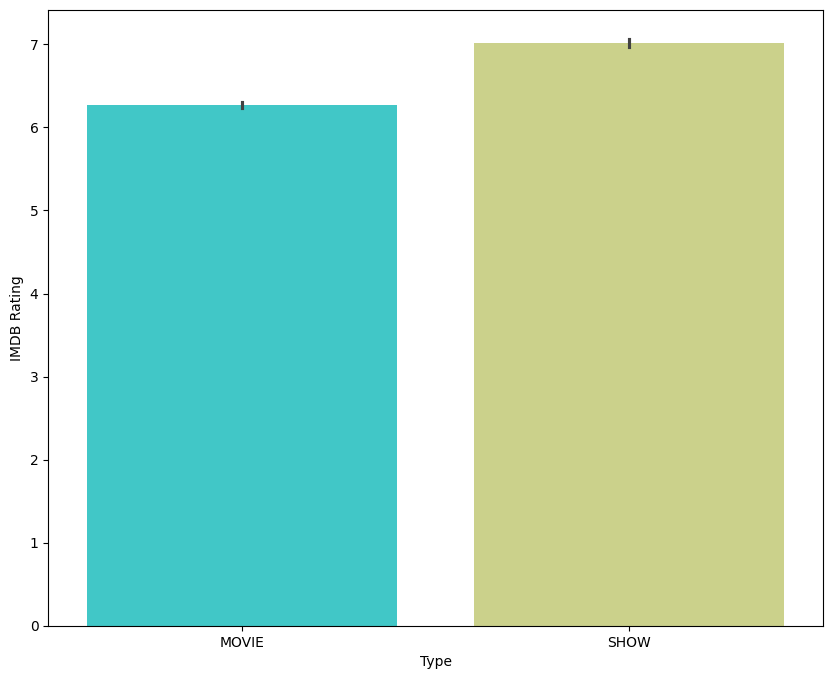

In [17]:
plt.figure(figsize=(10,8))
sns.barplot(data=df,x='type',y='imdb_score',hue='type',palette='rainbow')
plt.xlabel("Type")
plt.ylabel("IMDB Rating")
plt.show()

                                     IMDB Rating is  Better fot TV Shows

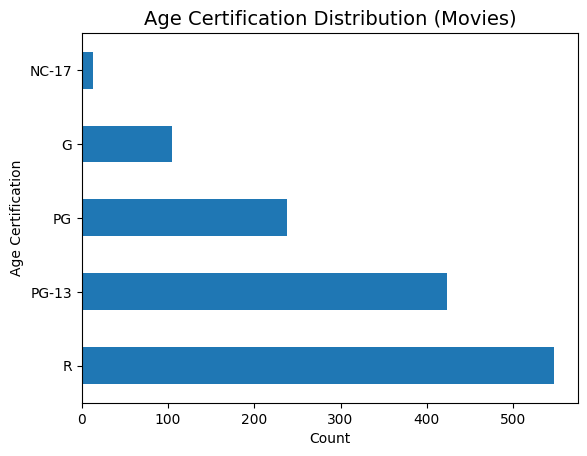

In [26]:
movie_df = df[(df['type'] == 'MOVIE') & (df['age_certification'] != 'Unknown')]

age_count = movie_df['age_certification'].value_counts()

age_count.plot(kind='barh')

plt.title("Age Certification Distribution (Movies)", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Age Certification")
plt.show()

              In the case of movies, R rated content is the most available on Netflix.

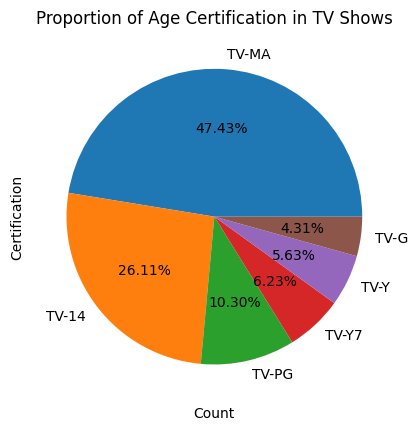

In [33]:
show_df = df[(df['type'] == 'SHOW') & (df['age_certification'] != 'Unknown')]

age_cert = show_df['age_certification'].value_counts()

plt.pie(age_cert,labels=age_cert.index,autopct='%1.2f%%')
plt.title("Proportion of Age Certification in TV Shows")
plt.xlabel("Count")
plt.ylabel("Certification")
plt.show()

In the case of TV-Shows, TV-MA is the most available, which is the equivalent of R rating in Movie segment.

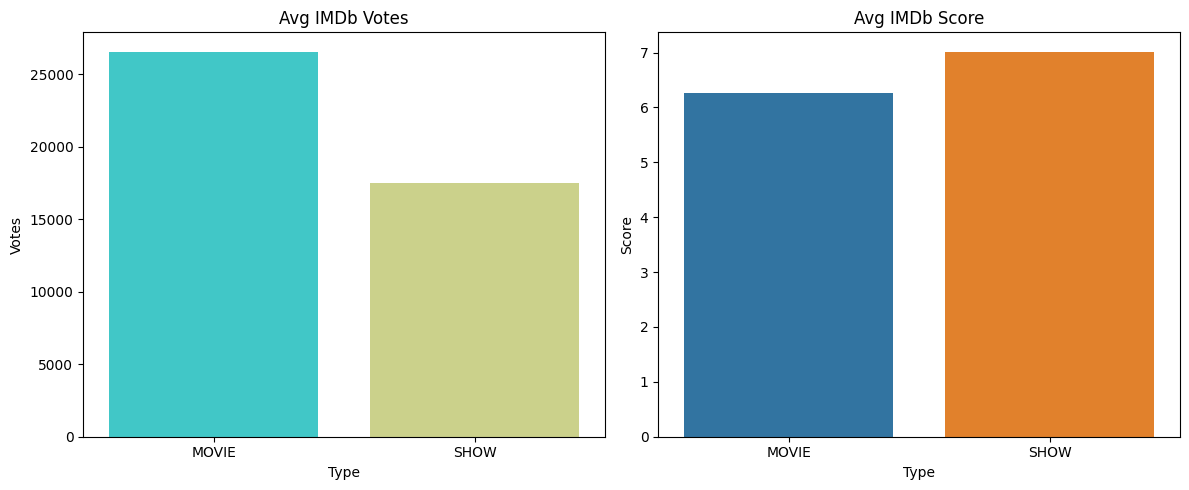

In [48]:
avg_vote_type = df.groupby('type')['imdb_votes'].mean().reset_index()
avg_score_vote = df.groupby('type')['imdb_score'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Plot 1: Votes
sns.barplot(data=avg_vote_type,
            x='type',
            y='imdb_votes',hue='type',palette='rainbow',
            ax=axes[0])

axes[0].set_title("Avg IMDb Votes")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Votes")


# Plot 2: Score
sns.barplot(data=avg_score_vote,
            x='type',
            y='imdb_score',hue='type',
            ax=axes[1])

axes[1].set_title("Avg IMDb Score")
axes[1].set_xlabel("Type")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

                     Even though movies got much better votes than TV Shows but TV Show Outscores Movies in Imdb Scores

C:\Users\Sanja\AppData\Local\Temp\ipykernel_20680\1131016149.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_certi,x='age_certification',y='imdb_votes',ax=ax[0],palette='rainbow')
C:\Users\Sanja\AppData\Local\Temp\ipykernel_20680\1131016149.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=age_cert_tv,x='age_certification',y='imdb_votes',ax=ax[1],palette='rainbow')


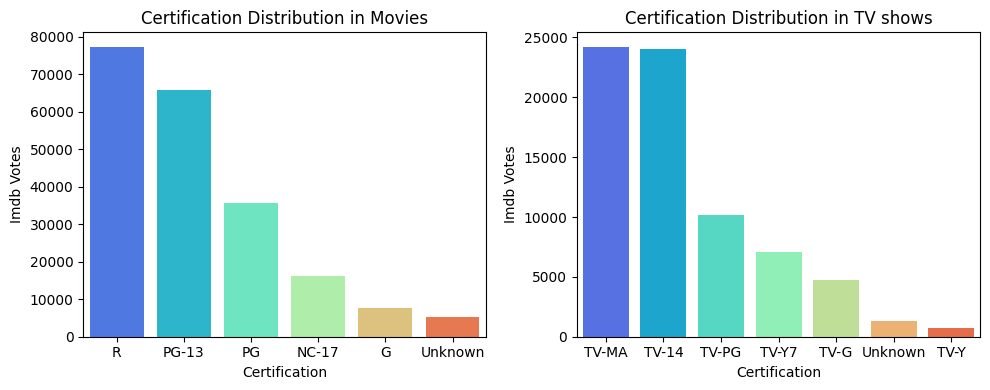

In [82]:
movie_d=df[df['type']=='MOVIE']
tv_df1=df[df['type']=='SHOW']

age_certi=movie_d.groupby('age_certification')['imdb_votes'].mean().reset_index().sort_values(by='imdb_votes',ascending=False)
age_cert_tv=tv_df1.groupby('age_certification')['imdb_votes'].mean().reset_index().sort_values(by='imdb_votes',ascending=False)
fig,ax=plt.subplots(1,2,figsize=(10,4))

sns.barplot(data=age_certi,x='age_certification',y='imdb_votes',ax=ax[0],palette='rainbow')
ax[0].set_title("Certification Distribution in Movies")
ax[0].set_xlabel("Certification")
ax[0].set_ylabel("Imdb Votes")

sns.barplot(data=age_cert_tv,x='age_certification',y='imdb_votes',ax=ax[1],palette='rainbow')
ax[1].set_title("Certification Distribution in TV shows")
ax[1].set_xlabel("Certification")
ax[1].set_ylabel("Imdb Votes")

plt.tight_layout()
plt.show()





Higher age ratings have significantly high votes indicating higer viewership for R rated movies and TV-MA rated shows, which are also the most available certifications on Netflix.

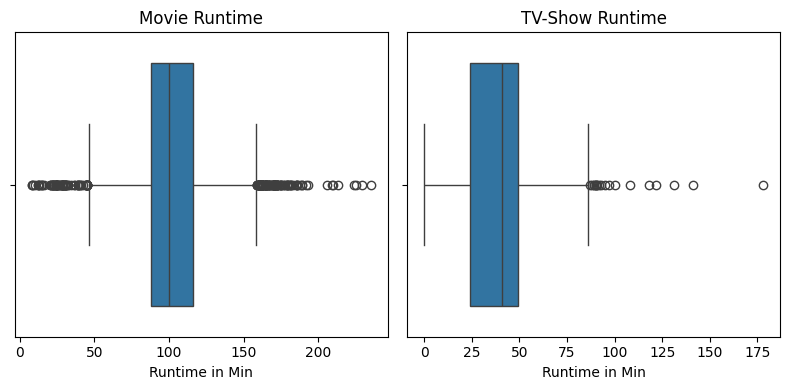

In [52]:
movie_df1=df[df['type']=='MOVIE']
tv_df=df[df['type']=="SHOW"]


fig,ax=plt.subplots(1,2,figsize=(8,4))

#Plot1
sns.boxplot(data=df,x=movie_df1['runtime'],ax=ax[0])
ax[0].set_title("Movie Runtime")
ax[0].set_xlabel("Runtime in Min")

#Plot2
sns.boxplot(data=df,x=tv_df['runtime'],ax=ax[1])
ax[1].set_title("TV-Show Runtime")
ax[1].set_xlabel("Runtime in Min")

plt.tight_layout()
plt.show()


                                       Movies → Avg Runtime of 100min(median)
                                       TV Shows → Avg runtime of 40min(median)

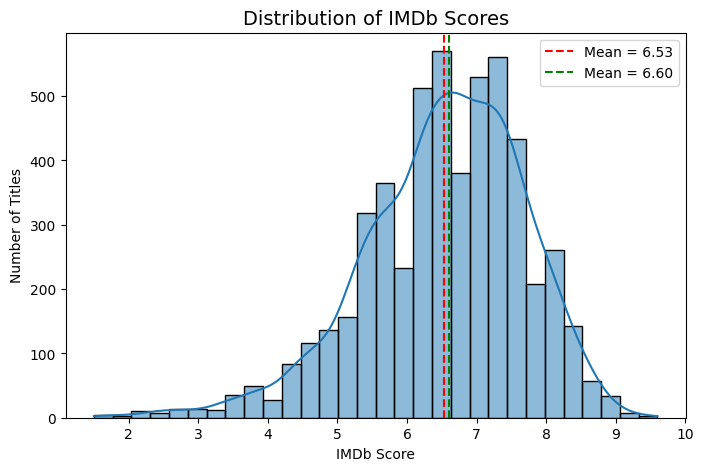

In [58]:
plt.figure(figsize=(8,5))
sns.histplot(df['imdb_score'], bins=30, kde=True)

plt.axvline(
    df['imdb_score'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean = {df['imdb_score'].mean():.2f}"
)

plt.axvline(df['imdb_score'].median(),
            color='green',linestyle='--',
            label=f"Mean = {df['imdb_score'].median():.2f}")


plt.title("Distribution of IMDb Scores", fontsize=14)
plt.xlabel("IMDb Score")
plt.ylabel("Number of Titles")
plt.legend()
plt.show()

The Shows and Movies on Netflix have an average rating of 6.53 which indicates that most of the movies and shows are of top quality.

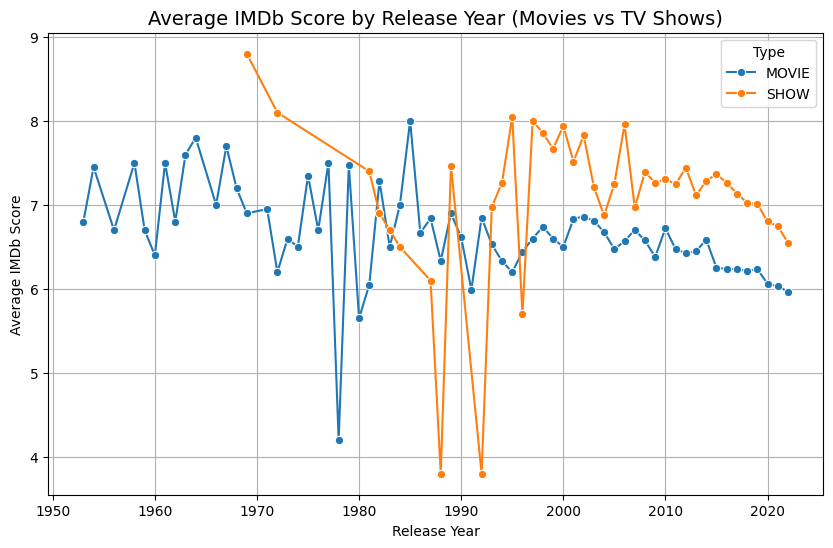

In [68]:
avg_score=df.groupby(['release_year','type'])['imdb_score'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=avg_score,x='release_year',y='imdb_score',hue='type',marker='o')
plt.title("Average IMDb Score by Release Year (Movies vs TV Shows)", fontsize=14)
plt.xlabel("Release Year")
plt.ylabel("Average IMDb Score")
plt.legend(title="Type")
plt.grid(True)
plt.show()

The chart shows TV Shows released around 1970 has highest imdb score and falls rapidly between 1988 and 1992.Movies released in 1985 has the highest rating and lowest at 1978 but movies are way more consistant than Tv shows.



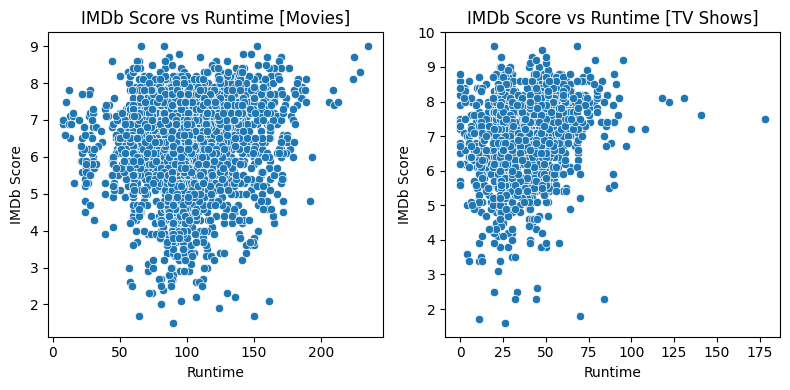

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

# Movies
sns.scatterplot(data=df[df['type'] == 'MOVIE'],
                x='runtime',
                y='imdb_score',
                ax=ax[0])

ax[0].set_title("IMDb Score vs Runtime [Movies]")
ax[0].set_xlabel("Runtime")
ax[0].set_ylabel("IMDb Score")


# TV Shows
sns.scatterplot(data=df[df['type'] == 'SHOW'],
                x='runtime',
                y='imdb_score',
                ax=ax[1])

ax[1].set_title("IMDb Score vs Runtime [TV Shows]")
ax[1].set_xlabel("Runtime")
ax[1].set_ylabel("IMDb Score")

plt.tight_layout()
plt.show()

Movies and shows both have all ratings distributed all over the median runtime zone. But, both plots show that the higher the runtime, the higher the rating.

In the case of movies, we can see that movies will lower runtime also have higher rating.

In [73]:
df.head(2)

,index,title,type,release_year,age_certification,runtime,imdb_score,imdb_votes
0,0,Taxi Driver,MOVIE,1976,R,113,8.3,795222.0
1,1,Monty Python and the Holy Grail,MOVIE,1975,PG,91,8.2,530877.0


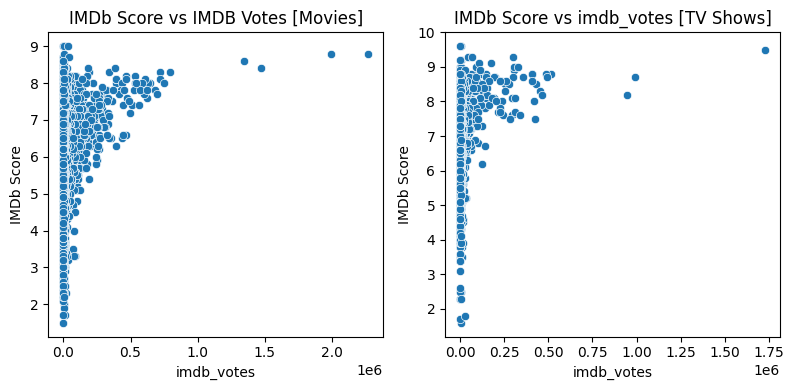

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(8,4))

# Movies
sns.scatterplot(data=df[df['type'] == 'MOVIE'],
                x='imdb_votes',
                y='imdb_score',
                ax=ax[0])

ax[0].set_title("IMDb Score vs IMDB Votes [Movies]")
ax[0].set_xlabel("imdb_votes")
ax[0].set_ylabel("IMDb Score")


# TV Shows
sns.scatterplot(data=df[df['type'] == 'SHOW'],
                x='imdb_votes',
                y='imdb_score',
                ax=ax[1])

ax[1].set_title("IMDb Score vs imdb_votes [TV Shows]")
ax[1].set_xlabel("imdb_votes")
ax[1].set_ylabel("IMDb Score")

plt.tight_layout()
plt.show()

Popularity slightly increases rating, but the relationship is weak and inconsistent.

TV shows show a clearer positive relationship between popularity and rating.

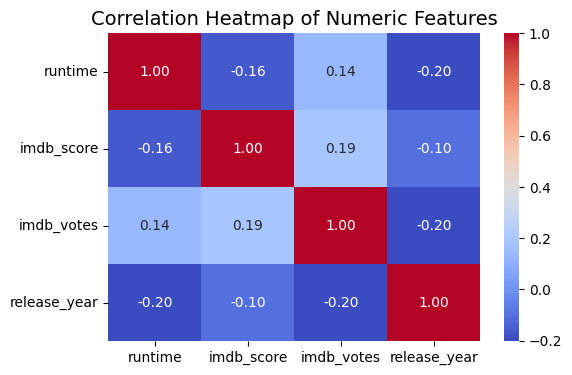

In [83]:
num_cols = ['runtime', 'imdb_score', 'imdb_votes', 'release_year']

corr = df[num_cols].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr,
    annot=True,                   
    fmt=".2f",
    cmap='coolwarm')

plt.title("Correlation Heatmap of Numeric Features", fontsize=14)
plt.show()

Nothing strongly affects IMDb score  
Votes, runtime, and year have only weak influence